Game: Player 2 wins
[0, 1]
Change sides, short break
Game: Player 2 wins
[1, 1]
Game: Player 2 wins
[1, 2]
Change sides, 1 minute break
Game, player 2 broke
[1, 3]
Game: Player 2 wins
[1, 4]
Change sides, 1 minute break
Game, player 2 broke
[1, 5]
Game: Player 2 wins
[1, 6]
Change sides, 1 minute break
Sets:  [0, 1]
Start new set and 2 minute break
Game: Player 2 wins
[0, 1]
Change sides, short break
Game, player 2 broke
[0, 2]
Game: Player 2 wins
[0, 3]
Change sides, 1 minute break
Game, player 2 broke
[0, 4]
Game: Player 2 wins
[0, 5]
Change sides, 1 minute break
Game: Player 2 wins
[1, 5]
Game: Player 2 wins
[1, 6]
Change sides, 1 minute break
Game, Set, Match: Player 2
Game: Player 2 wins
[1, 0]
Change sides, short break
Game, player 1 broke
[2, 0]
Game: Player 2 wins
[3, 0]
Change sides, 1 minute break
Game: Player 2 wins
[3, 1]
Game: Player 2 wins
[4, 1]
Change sides, 1 minute break
Game: Player 2 wins
[4, 2]
Game: Player 2 wins
[5, 2]
Change sides, 1 minute break
Game: Player 2 

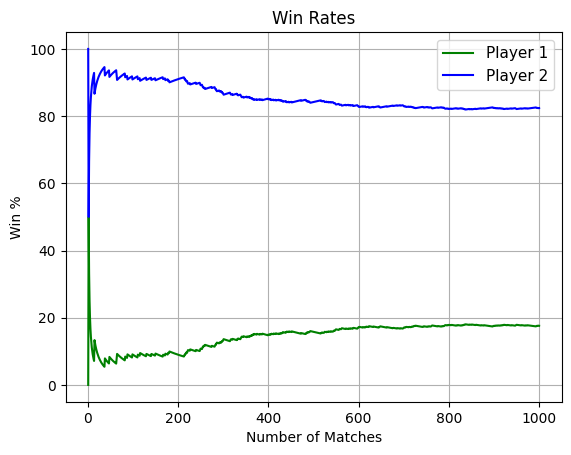

In [254]:


import random



score = (0, 0)
games = (0, 0)
tiebreak = (0, 0)
sets = (0, 0)
if games != (6, 6):
     server = random.choice([0, 1])
match = [0, 0]

def tennis_score_counter(sets, games, tiebreak, score, point, server):     
          sum_fifteen = [0, 15, 45]
          sum_ten = [30]
          sum_five = [40]
          sub_five = [45]
          long_break = (3, 5, 7, 9, 11, 13)



          games = list(games)
          sets = list(sets)
          tiebreak = list(tiebreak)
          sets = list(sets)


          if games != [6, 6]:
               for x in [score, point]: 
                    if not isinstance(x, tuple):
                         raise TypeError(f"Invalid entry: {x} is not a tuple()")
                    
               score = list(score)

               # Check for correct score notation and game count
               for i, s in enumerate(score):
                    if score[i] == 60:  
                         print(f"Game: Player {i+1} wins")
                    elif s not in [0, 15, 30, 40, 45]:
                         raise ValueError(f"Invalid score: {score}, {s} not a valid score")



               for j, s in enumerate(score): 

                    if point[j] == 1:
                         winner = j
                         if s in sum_fifteen:
                              score[j] += 15
                              
                         elif s in sum_ten:
                              score[j] += 10
                         elif score[1-j] == 45:
                                   if score[1-j] == 45:
                                        score[1-j] -= 5
                         elif s in [40]:  
                              if score[0] == score[1]:
                                   score[j] += 5    
                              else:
                                   score[j] += 20                                     
                    if score[j] == 60:
                              winner = j
                              if score[server] == 60:
                                   print(f"Game: Player {i+1} wins")
                              elif score[1 - server] == 60:
                                   print(f"Game, player {2 - server} broke") 
                              games[winner] += 1
                              score = [0, 0]
                              print(games)
                              if sum(games) == 1:
                                   print(f"Change sides, short break")
                              elif sum(games) in long_break:
                                   print(f"Change sides, 1 minute break")                           
                    elif point[j] != 1:
                         score[j] = score[j] 
         


          elif games == [6, 6]:
               if tiebreak == [0, 0]:
                    print("Games: 6/6. Start tiebreaker.")  
               for i, p in enumerate(point):
                    if point[i] == 1:
                         p_winner = i 
                         tiebreak[p_winner] += 1
                         print(tiebreak)
                         if sum(tiebreak) % 2 == 1:
                                        print(f"Change server")
                                        server = (1 - server)
                         if sum(tiebreak) % 6 == 0:
                                        print("Change sides")                                   
                         if tiebreak[p_winner] >= 7 and (tiebreak[p_winner] - tiebreak[1-p_winner] >= 2):
                                        games[i] += 1
                                        t2 = tiebreak[1-i]
                                        print(f"Set, player {i+1}, Games: 7/6({t2})")
                                        sets[i] += 1
                                        games = [0, 0]
                                        tiebreak = [0, 0]
                                        score = [0, 0]
                                        break


          for x in games:
               if not isinstance(x, int):
                    raise TypeError(f"{x} in Games is not valid type, got ", type(x))
               
          for x in games:
               if x not in [0, 1, 2, 3, 4, 5, 6, 7]:
                    raise ValueError(f"Games value is not valid, got {x}")


     
          
          for i, g in enumerate(games):
               if g == 7:
                    if games[1-i] in [5, 6]:
                         sets[i] += 1
                         if sets[i] != 2:
                              print("Sets: ", sets)
                              print("Start new set and 2 minute break")
                         else:
                              print(f"Game, Set, Match: Player {i+1}")
                         games = [0, 0]
               elif g == 6:
                    if games[1-i] in [0, 1, 2, 3, 4]:
                         sets[i] += 1                          
                         if sets[i] != 2:
                              print("Sets: ", sets)
                              print("Start new set and 2 minute break")
                         else:
                              print(f"Game, Set, Match: Player {i+1}")
                         games = [0, 0]
                         
          


          games = tuple(games)
          sets = tuple(sets)
          tiebreak = tuple(tiebreak)
          score = tuple(score)                          
          

          

          return sets, games, tiebreak, score, point, server


p1 = {
     "first_won": 0.699,
     "first_in": 0.641,
     "second_won": 0.546
}

p2 = {
     "first_won": 0.805,
     "first_in": 0.65,
     "second_won": 0.592
}

prob_p1 = (p1["first_won"] * p1["first_in"]) + (((1-p1["first_in"])) * p1["second_won"])
prob_p2 = (p2["first_won"] * p2["first_in"]) + (((1-p2["first_in"])) * p2["second_won"])

num_matches = 1000
match = [0, 0]
p1_win_rate = []
p2_win_rate = []


for m in range(num_matches):
     score = (0, 0)
     games = (0, 0)
     tiebreak = (0, 0)
     sets = (0, 0)
     server = random.choice([0, 1])

     while sets[0] < 2 and sets[1] < 2:
          if server == 0:
               serve_prob_p1 = prob_p1
               serve_prob_p2 = 1 - serve_prob_p1
          else:
               serve_prob_p2 = prob_p2
               serve_prob_p1 = 1 - serve_prob_p2
          if random.random() < serve_prob_p1:
               point = (1, 0)
          else:
               point = (0, 1)
          games_before = sum(games)

          sets, games, tiebreak, score, point, server = tennis_score_counter(sets, games, tiebreak, score, point, server)
          if games_before < sum(games):
               server = 1 - server

     for i in range(2):
          if sets[i] == 2:
               match[i] += 1
               
     p1_win_rate.append(match[0] / (match[0]+match[1]) * 100)      
     p2_win_rate.append(match[1] / (match[0]+match[1]) * 100)
               

print("Matches won:", match)
print("Player 1 win %:", round(match[0] / num_matches * 100, 1))
print("Player 2 win %:", round(match[1] / num_matches * 100, 1))





           
if games != (6, 6):
     print("Match:", match, "Sets:", sets, "Games:", games, "Score:", score)
else:
     print("Match:", match, "Sets:", sets, "Games:", games, "Score:", score, "Tiebreak:", tiebreak)

import matplotlib.pyplot as plt
num_matches = range(1, (num_matches + 1))

x, y, y1 = num_matches, p1_win_rate, p2_win_rate

plt.title("Win Rates")
plt.xlabel("Number of Matches")
plt.ylabel("Win %")

plt.plot(x, y, color="green", label="Player 1")
plt.plot(x, y1, color="blue", label="Player 2")
plt.legend(loc="upper right", fontsize=11)
plt.grid()
plt.show()